In [14]:
#Cell 1 — Setup
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

PROJECT_ROOT = Path("..").resolve()
FEATURE_DIR = PROJECT_ROOT / "inara_data" / "features"

print("Project root:", PROJECT_ROOT)
print("Feature dir:", FEATURE_DIR)

Project root: /Users/bhalchandra/PycharmProjects/inara-atmospheric-composition
Feature dir: /Users/bhalchandra/PycharmProjects/inara-atmospheric-composition/inara_data/features


In [15]:
#### Cell 2 — Load engineered features
X = np.load(FEATURE_DIR / "X.npy")
targets = np.load(FEATURE_DIR / "targets.npy")

print("X shape:", X.shape)
print("targets shape:", targets.shape)

X shape: (10000, 74)
targets shape: (10000, 12)


In [16]:
#### Cell 3 — Create a DataFrame for inspection
# Feature names are not currently saved by the feature engineering script,
# so we use generic names for now.
feature_names = [f"feature_{i}" for i in range(X.shape[1])]

df = pd.DataFrame(X, columns=feature_names)
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73
0,0.575360,0.298471,0.000000,0.892052,0.482166,0.714958,0.792022,0.509109,0.515240,0.820785,...,13.032069,10.934243,11.555177,6.762014,13.002939,1076.0,1.844814,3.0,3297.899902,0.070143
1,0.555096,0.138779,0.000000,0.832651,0.490748,0.598823,0.647540,0.307482,0.333745,0.619089,...,11.121981,9.075348,2.612553,8.915923,4.705198,804.0,1.639910,2.0,4582.799805,0.015382
2,0.705984,0.148353,0.000000,1.000000,0.570729,0.719262,0.793480,0.508671,0.504154,0.783060,...,9.594155,7.465746,12.614869,15.393383,13.853591,1258.0,4.193661,2.0,4032.500000,0.051660
3,0.484701,0.124024,0.192190,0.714041,0.426943,0.499251,0.584341,0.291636,0.285844,0.612585,...,6.917692,6.532570,4.620173,4.504753,5.797728,663.0,1.431364,2.0,5086.299805,0.004376
4,0.696973,0.106217,0.432845,0.993045,0.613496,0.721847,0.770834,0.541694,0.550041,0.770795,...,8.397686,6.055072,2.130971,3.707256,7.536528,1320.0,2.760052,2.0,4244.399902,0.054751


In [17]:
#### Cell 4 — Check missing, NaN, and infinite values
summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "nan_count": df.isna().sum(),
    "inf_count": np.isinf(df.to_numpy()).sum(axis=0),
})

summary["total_problem_values"] = (
    summary["null_count"] + summary["nan_count"] + summary["inf_count"]
)

summary = summary.sort_values("total_problem_values", ascending=False)
summary.head(20)

,null_count,nan_count,inf_count,total_problem_values
feature_0,0,0,0,0
feature_55,0,0,0,0
feature_53,0,0,0,0
feature_52,0,0,0,0
feature_51,0,0,0,0
feature_50,0,0,0,0
feature_49,0,0,0,0
feature_48,0,0,0,0
feature_47,0,0,0,0
feature_46,0,0,0,0


In [18]:
#### Cell 5 — Overall data quality summary
arr = df.to_numpy()

total_cells = arr.size
total_nulls = df.isnull().sum().sum()
total_nans = np.isnan(arr).sum()
total_infs = np.isinf(arr).sum()

print(f"Rows: {df.shape[0]}")
print(f"Cols: {df.shape[1]}")
print(f"Total cells: {total_cells}")
print(f"Nulls: {total_nulls}")
print(f"NaNs: {total_nans}")
print(f"Infinities: {total_infs}")
print(f"Problem ratio: {(total_nulls + total_nans + total_infs) / total_cells:.4%}")

Rows: 10000
Cols: 74
Total cells: 740000
Nulls: 0
NaNs: 0
Infinities: 0
Problem ratio: 0.0000%


In [19]:
#### Cell 6 — Check constants and low-variance features
feature_stats = pd.DataFrame({
    "mean": df.mean(),
    "std": df.std(),
    "min": df.min(),
    "max": df.max(),
})

feature_stats["is_constant"] = feature_stats["std"] == 0
feature_stats["is_near_constant"] = feature_stats["std"] < 1e-8

feature_stats.sort_values("std").head(20)

,mean,std,min,max,is_constant,is_near_constant
feature_17,0.000018,0.000038,-0.000182,0.000237,False,False
feature_18,0.012284,0.007836,0.004757,0.053044,False,False
feature_1,0.143028,0.035322,0.088242,0.425884,False,False
feature_73,0.040124,0.044114,0.002282,1.620541,False,False
feature_4,0.544137,0.070085,0.000000,0.804083,False,False
feature_0,0.630729,0.071955,0.412157,0.879278,False,False
feature_5,0.661310,0.074124,0.445588,0.945553,False,False
feature_9,0.709375,0.075412,0.490762,0.970935,False,False
feature_3,0.920915,0.077813,0.640785,1.000000,False,False
feature_10,0.712991,0.079654,0.490144,0.999305,False,False


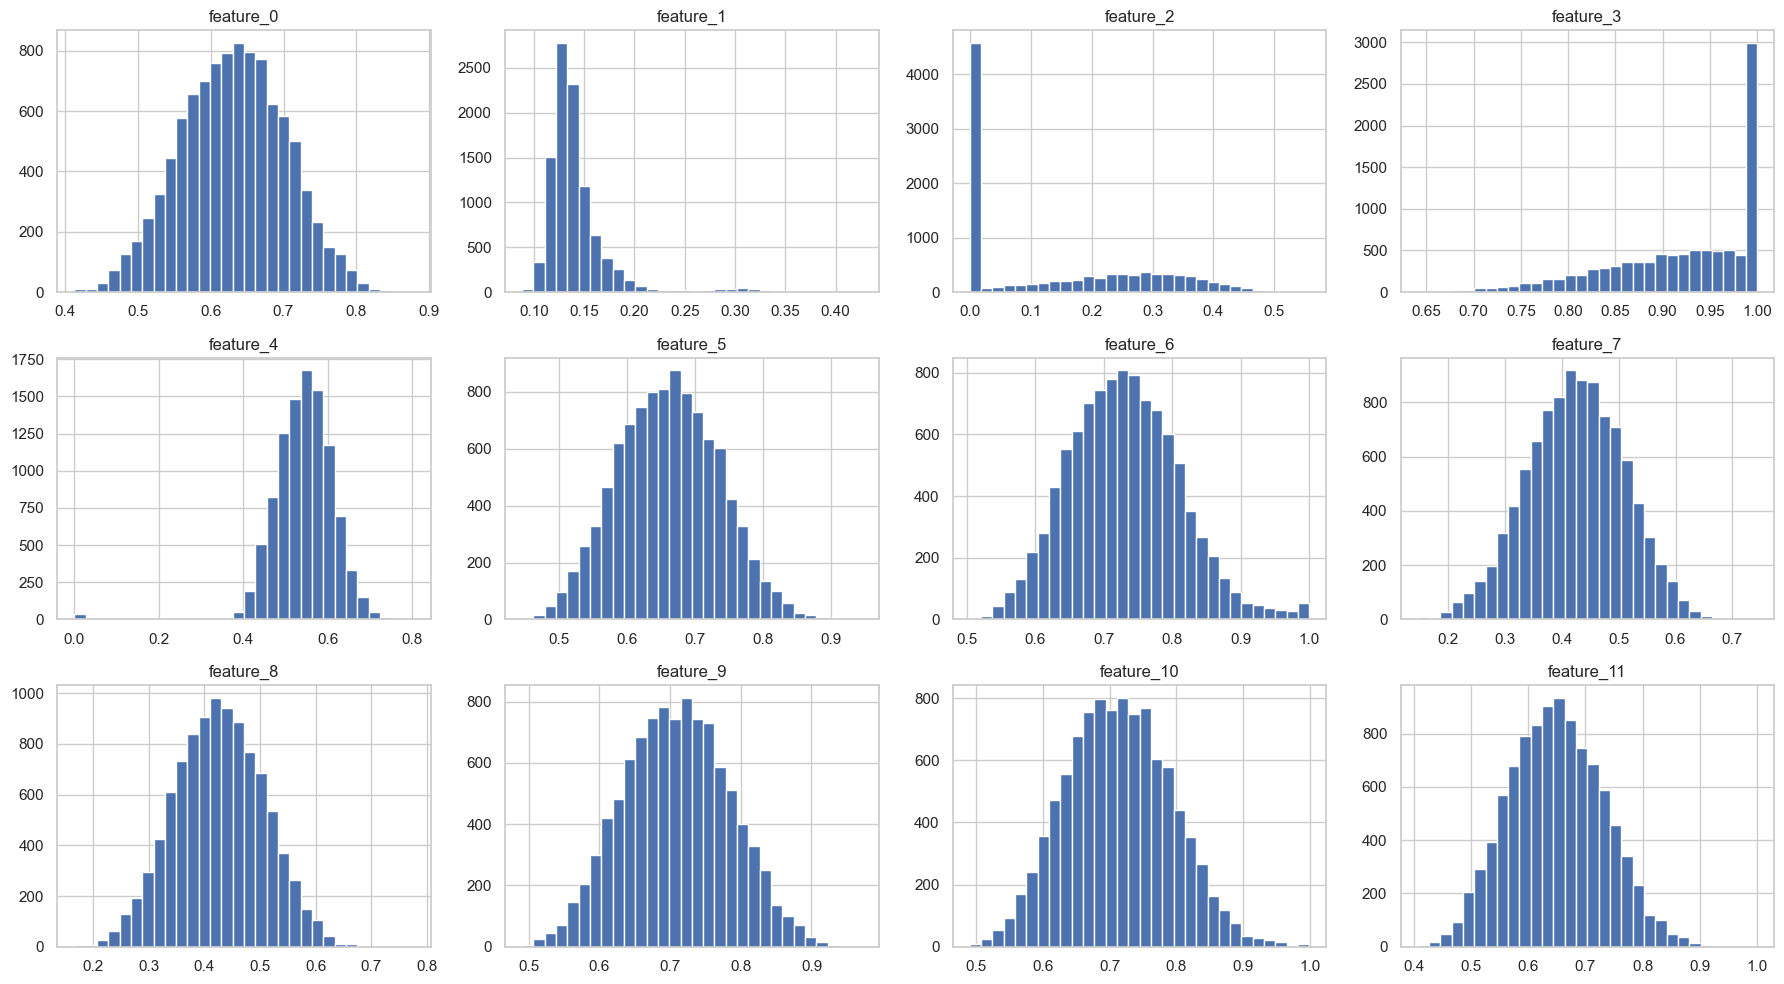

In [20]:
#### Cell 7 — Distribution plots
sample_cols = df.columns[:12]  # adjust if you want more/less
df[sample_cols].hist(bins=30, figsize=(18, 10), layout=(3, 4))
plt.tight_layout()
plt.show()

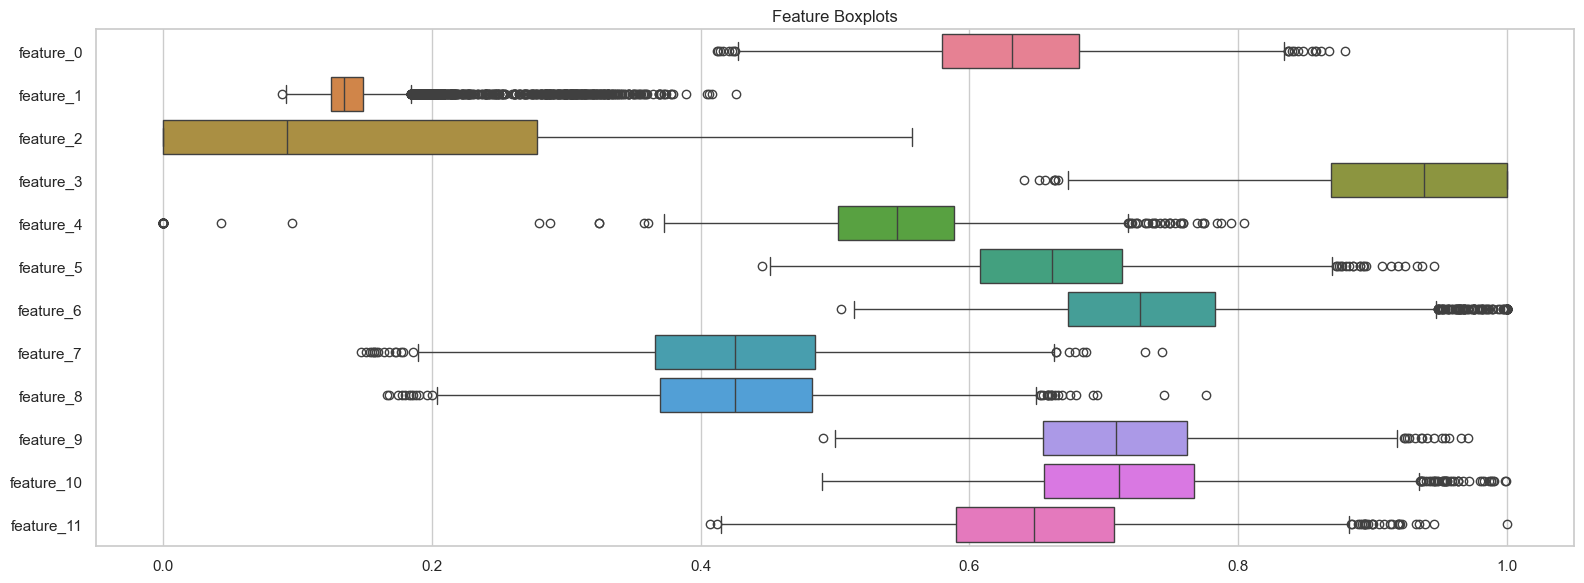

In [21]:
#### Cell 8 — Boxplots for outlier inspection
sample_cols = df.columns[:12]

plt.figure(figsize=(16, 6))
sns.boxplot(data=df[sample_cols], orient="h")
plt.title("Feature Boxplots")
plt.tight_layout()
plt.show()

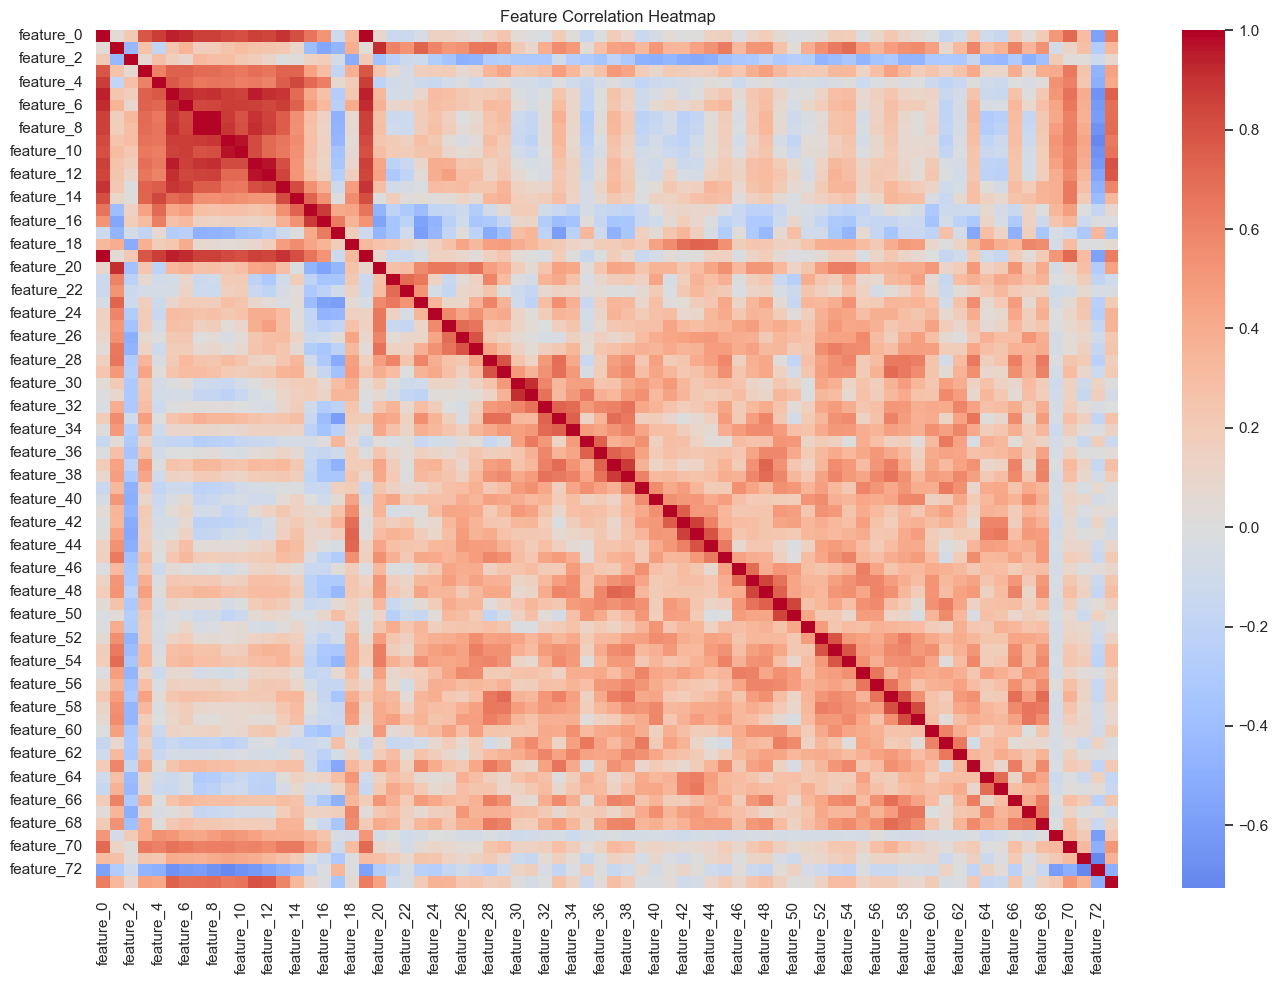

In [22]:
#### Cell 9 — Correlation heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [23]:
#### Cell 10 — Target inspection
target_df = pd.DataFrame(targets)
print("Target shape:", target_df.shape)

target_nulls = target_df.isna().sum()
target_stats = target_df.describe().T

display(target_nulls.to_frame("missing_count"))
display(target_stats)

Target shape: (10000, 12)


,missing_count
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


,count,mean,std,min,25%,50%,75%,max
0,10000.0,-1.903067,1.362538,-5.672558,-3.389428,-1.206488,-0.925241,0.000000
1,10000.0,-2.242839,0.890890,-6.032210,-2.526457,-2.192060,-1.881717,0.000000
2,10000.0,-1.680508,0.529481,-4.762101,-2.086953,-1.825782,-1.276130,-0.243518
3,10000.0,-6.135971,0.407668,-8.000000,-6.420865,-6.129232,-5.845900,-3.967885
4,10000.0,-4.888174,0.825660,-7.196193,-5.446652,-5.077686,-4.538410,-1.523361
5,10000.0,-1.049205,0.732009,-4.511292,-1.541824,-1.010534,-0.480023,0.000000
6,10000.0,-6.456718,0.946804,-8.000000,-7.161464,-6.481718,-5.815013,-2.817491
7,10000.0,-5.480365,1.445292,-8.000000,-6.514379,-5.517942,-4.501381,0.000000
8,10000.0,-4.465279,1.491197,-8.000000,-5.493951,-4.486367,-3.456905,0.000000
9,10000.0,-5.998895,1.139579,-8.000000,-6.827255,-6.034606,-5.222107,0.000000


In [24]:
#### Cell 11 — Target balance / sparsity
# Useful if targets are multi-label / sparse
positive_counts = target_df.sum(axis=0)
positive_rate = positive_counts / len(target_df)

target_summary = pd.DataFrame({
    "positive_count": positive_counts,
    "positive_rate": positive_rate
})

target_summary.sort_values("positive_rate", ascending=False)

,positive_count,positive_rate
5,-10492.054688,-1.049205
2,-16805.093750,-1.680509
0,-19030.644531,-1.903064
1,-22428.390625,-2.242839
8,-44652.765625,-4.465277
4,-48881.789062,-4.888179
7,-54803.742188,-5.480374
11,-59259.003906,-5.925900
9,-59988.894531,-5.998889
3,-61359.781250,-6.135978


In [25]:
#### Cell 12 — Save report
report_dir = PROJECT_ROOT / "results"
report_dir.mkdir(parents=True, exist_ok=True)

summary_path = report_dir / "post_fe_check_summary.csv"
feature_stats_path = report_dir / "post_fe_feature_stats.csv"
target_summary_path = report_dir / "post_fe_target_summary.csv"

summary.to_csv(summary_path)
feature_stats.to_csv(feature_stats_path)
target_summary.to_csv(target_summary_path)

print("Saved:")
print(summary_path)
print(feature_stats_path)
print(target_summary_path)

Saved:
/Users/bhalchandra/PycharmProjects/inara-atmospheric-composition/results/post_fe_check_summary.csv
/Users/bhalchandra/PycharmProjects/inara-atmospheric-composition/results/post_fe_feature_stats.csv
/Users/bhalchandra/PycharmProjects/inara-atmospheric-composition/results/post_fe_target_summary.csv
